# Benutzeranleitung: Simulation und exakte Berechnung bei Chip-Abräumspielen

Dieses Programm untersucht die Gewinnwahrscheinlichkeiten bei **Chip-Abräumspielen**.  
Es kombiniert **Simulation** (Monte-Carlo-Experimente) mit **exakter Berechnung** (über Brüche, `Fraction`).

---

## Eingaben
- **p**: Trefferwahrscheinlichkeiten der Felder (Liste, Summe = 1).  
  Beispiel: `p = [1/2, 1/3, 1/6]`
- **A**: Verteilung der Chips von Spieler A (Liste ganzer Zahlen).  
  Beispiel: `A = [3, 2, 1]`
- **B**: Verteilung der Chips von Spieler B.  
  Beispiel: `B = [4, 2, 0]`
- **n_values**: Liste mit verschiedenen Stichprobenumfängen für die Simulation.  
  Beispiel: `n_values = [100, 400, 1600]`
  
## Hinweise zur Benutzung

- Die relevanten Parameter befinden sich im Code am Ende:  

  ```python
  p = [Fraction(1, 2), Fraction(1, 3), Fraction(1, 6)]
  A = [3, 2, 1]
  B = [4, 2, 0]
  n_values = [100, 400, 1600]
  
  ```
  </br>


### ▶️ Ausführen des Programms

- Klicken Sie in die Code-Zelle.
- Drücken Sie `Shift + Enter`, um die Berechnung zu starten.  
  Alternativ können Sie auch auf **▶ Run** oben in der Werkzeugleiste klicken.
- Über **Run → Run all cells** werden alle Zellen auf einmal ausgeführt.

---

## Ausgaben
1. **Simulationsergebnisse**:
   - relative Häufigkeiten (`phat`) für „A gewinnt“, „B gewinnt“ und „Unentschieden“
   - 95-%-Konfidenzintervalle (Wilson-Intervalle)
   - Abweichung vom exakten Wert  

   → Ausgabe in der Konsole in Tabellenform.  

2. **Exakte Berechnung** (mittels `Fraction`):  
   - liefert **genaue Brüche** für die drei Wahrscheinlichkeiten.  
   - wird zusätzlich als **Dezimalzahl** angezeigt. </br></br>



3. **Grafik** (Balkendiagramm):  
   - blaue Balken = Ergebnisse der Simulation  
   - schwarze Fehlerbalken = Unsicherheit (Konfidenzintervalle)  
   - rote Punkte = exakte Werte  
   - Vergleich für alle gewählten Stichprobenumfänge nebeneinander  

---

## Was man ausprobieren kann
- Ändern Sie die Wahrscheinlichkeiten `p` (z. B. gleichverteilt oder sehr ungleich verteilt).  
- Variieren Sie die Chipverteilungen von A und B.  
- Ändern Sie die Stichprobenumfänge `n_values` (z. B. 100, 1000, 10000).  

---


--- Ergebnisse für n = 100 ---
A gewinnt      : phat = 0.48000, CI = (0.38464 – 0.57684), Abweichung = 0.01247, exakt = 1181921/2400000
B gewinnt      : phat = 0.29000, CI = (0.21015 – 0.38539), Abweichung = 0.03609, exakt = 65/256
Unentschieden  : phat = 0.23000, CI = (0.15843 – 0.32155), Abweichung = 0.02363, exakt = 9511/37500

--- Ergebnisse für n = 400 ---
A gewinnt      : phat = 0.50250, CI = (0.45371 – 0.55124), Abweichung = 0.01003, exakt = 1181921/2400000
B gewinnt      : phat = 0.23500, CI = (0.19609 – 0.27895), Abweichung = 0.01891, exakt = 65/256
Unentschieden  : phat = 0.26250, CI = (0.22179 – 0.30773), Abweichung = 0.00887, exakt = 9511/37500

--- Ergebnisse für n = 1600 ---
A gewinnt      : phat = 0.50125, CI = (0.47678 – 0.52572), Abweichung = 0.00878, exakt = 1181921/2400000
B gewinnt      : phat = 0.25188, CI = (0.23122 – 0.27372), Abweichung = 0.00203, exakt = 65/256
Unentschieden  : phat = 0.24688, CI = (0.22637 – 0.26859), Abweichung = 0.00675, exakt = 9511/37500


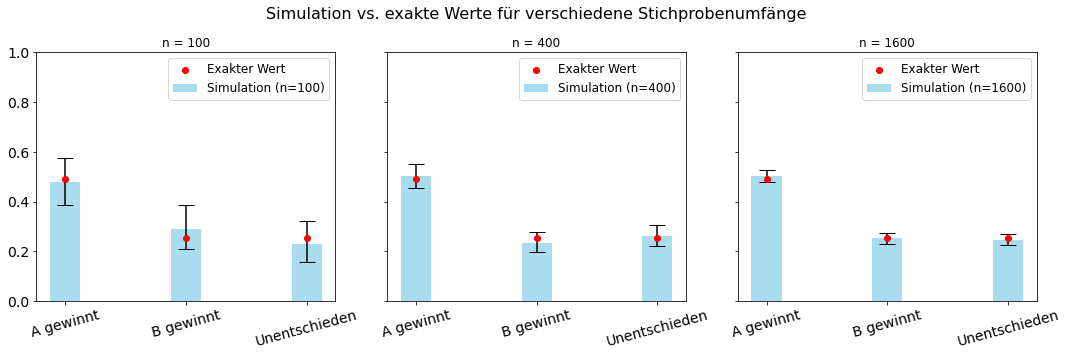

In [1]:
import random, math
from functools import lru_cache
from fractions import Fraction
import matplotlib.pyplot as plt

# --- Wilson-Intervall ---
def wilson_interval(k, n, z=1.96):
    if n == 0:
        return (0.0, 0.0)
    phat = k / n
    denom = 1 + z**2 / n
    center = (phat + z**2 / (2*n)) / denom
    halfwidth = z / denom * math.sqrt(phat*(1 - phat)/n + z**2 / (4*n**2))
    return center - halfwidth, center + halfwidth

# --- Simulation ---
def simulate_game(p, A, B):
    m = len(p)
    chips_A = A[:]
    chips_B = B[:]

    def fertig(chips):
        return all(c == 0 for c in chips)

    while True:
        r = random.random()
        s = 0
        for j in range(m):
            s += p[j]
            if r < s:
                feld = j
                break

        if chips_A[feld] > 0:
            chips_A[feld] -= 1
        if chips_B[feld] > 0:
            chips_B[feld] -= 1

        if fertig(chips_A) and fertig(chips_B):
            return 'U'
        elif fertig(chips_A):
            return 'A'
        elif fertig(chips_B):
            return 'B'

def simulate_many(p, A, B, n_runs=10000):
    counts = {'A': 0, 'B': 0, 'U': 0}
    for _ in range(n_runs):
        counts[simulate_game(p, A, B)] += 1

    results = {}
    for k in counts:
        phat = counts[k] / n_runs
        low, high = wilson_interval(counts[k], n_runs)
        results[k] = {"p_hat": phat, "CI_low": low, "CI_high": high}
    return results

# --- Exakte Berechnung mit Fraction ---
def exact_probabilities_fraction(p, A, B):
    p = tuple(Fraction(pi) for pi in p)
    A = tuple(A)
    B = tuple(B)

    @lru_cache(None)
    def P_A(V, W):
        sum_V, sum_W = sum(V), sum(W)
        if sum_V == 0 and sum_W == 0: return Fraction(0, 1)
        if sum_V == 0: return Fraction(1, 1)
        if sum_W == 0: return Fraction(0, 1)

        s = sum(pj for pj, vj, wj in zip(p, V, W) if vj or wj)
        if s == 0: return Fraction(0, 1)

        prob = Fraction(0, 1)
        for j, pj in enumerate(p):
            if V[j] or W[j]:
                Vn = V[:j] + (max(0, V[j]-1),) + V[j+1:]
                Wn = W[:j] + (max(0, W[j]-1),) + W[j+1:]
                prob += (pj / s) * P_A(Vn, Wn)
        return prob

    PA = P_A(A, B)
    PB = P_A(B, A)
    PU = Fraction(1, 1) - PA - PB
    return PA, PB, PU

# --- Mehrfach-n-Vergleich + Tabelle ---
if __name__ == "__main__":
    p = [Fraction(1, 2), Fraction(1, 3), Fraction(1, 6)]
    A = [3, 2, 1]
    B = [4, 2, 0]
    n_values = [100, 400, 1600]

    exact_vals = exact_probabilities_fraction(p, A, B)
    exact_floats = [float(v) for v in exact_vals]
    labels = ["A gewinnt", "B gewinnt", "Unentschieden"]

    fig, axes = plt.subplots(1, len(n_values), figsize=(5*len(n_values), 5), sharey=True)
    for ax in axes:
        ax.tick_params(axis='y', labelsize=14)

    for ax, n in zip(axes, n_values):
        sim = simulate_many([float(x) for x in p], A, B, n)
        sim_vals = [sim[k]["p_hat"] for k in ['A', 'B', 'U']]
        ci_lows = [sim[k]["CI_low"] for k in ['A', 'B', 'U']]
        ci_highs = [sim[k]["CI_high"] for k in ['A', 'B', 'U']]
        yerr = [[sim_vals[i] - ci_lows[i] for i in range(3)],
                [ci_highs[i] - sim_vals[i] for i in range(3)]]

        ax.bar(range(3), sim_vals, yerr=yerr, align='center', alpha=0.7, capsize=8,
               label=f"Simulation (n={n})", color='skyblue', width=0.25)
        ax.scatter(range(3), exact_floats, color='red', zorder=5, label="Exakter Wert")
        ax.set_xticks(range(3))
        ax.set_xticklabels(labels, rotation=15,fontsize=14)
        ax.set_ylim(0, 1)
        ax.set_title(f"n = {n}")
        ax.legend(fontsize=12)

        # --- Tabellenausgabe für dieses n ---
        print(f"\n--- Ergebnisse für n = {n} ---")
        for key, name, exact_val in zip(['A', 'B', 'U'], labels, exact_vals):
            phat = sim[key]["p_hat"]
            low  = sim[key]["CI_low"]
            high = sim[key]["CI_high"]
            deviation = abs(phat - float(exact_val))
            print(f"{name:15s}: phat = {phat:.5f}, CI = ({low:.5f} – {high:.5f}), "
                  f"Abweichung = {deviation:.5f}, exakt = {exact_val}")

    fig.suptitle("Simulation vs. exakte Werte für verschiedene Stichprobenumfänge", fontsize=16)
    plt.tight_layout()
    print() 
    plt.show()